In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
data_path = r"E:\src\neat-calculator\data_preprocessing\merged_sensor_data_labeled.json"

data = pd.read_json(data_path)

In [4]:
data.head()

,accelerometerX,accelerometerY,accelerometerZ,gyroscopeX,gyroscopeY,gyroscopeZ,timestamp,timestampNanos,label
0,-1.17,4.33,8.420000,0.19,0.02,-0.03,2025-12-31 11:56:24.050,1977-02-15 04:40:52.355298,STANDING
1,-1.17,4.33,8.420000,0.19,0.02,-0.03,2025-12-31 11:56:24.050,1977-02-15 04:40:52.355298,STANDING
2,-1.02,4.40,8.389999,0.19,0.02,-0.03,2025-12-31 11:56:24.072,1977-02-15 04:41:02.082069,STANDING
3,-1.02,4.40,8.389999,0.19,0.02,-0.03,2025-12-31 11:56:24.072,1977-02-15 04:41:02.082069,STANDING
4,-1.03,4.56,8.139999,0.08,0.04,0.00,2025-12-31 11:56:24.106,1977-02-15 04:41:32.798423,STANDING


In [5]:
data.describe()

,accelerometerX,accelerometerY,accelerometerZ,gyroscopeX,gyroscopeY,gyroscopeZ,timestamp,timestampNanos
count,102479.000000,102479.000000,102479.000000,102479.000000,102479.000000,102479.000000,102479,102479
mean,0.515906,9.629886,-1.289864,0.026531,-0.017108,0.036197,2025-12-31 13:14:46.678771968,1972-03-13 17:35:03.985789528
min,-19.490000,-17.760000,-16.130000,-12.490000,-5.600000,-6.360000,2025-12-31 11:56:24.050000,1970-01-01 16:03:58.720972
25%,-0.320000,9.540000,-1.960000,-0.020000,-0.130000,0.000000,2025-12-31 12:38:32.935000064,1970-01-09 19:25:48.403516
50%,1.100000,9.820000,-1.630000,0.030000,-0.020000,0.030000,2025-12-31 13:33:56.883000064,1970-01-11 03:33:08.750347
75%,1.370000,9.910000,-0.960000,0.070000,0.060000,0.080000,2025-12-31 13:35:44.893000192,1977-02-16 02:31:32.437351520
max,15.719999,19.430000,15.210000,9.929999,10.809999,4.810000,2025-12-31 13:39:06.270000,1977-03-17 13:29:58.620039
std,1.797991,1.422566,1.894636,0.303132,0.642270,0.275341,NaN,NaN


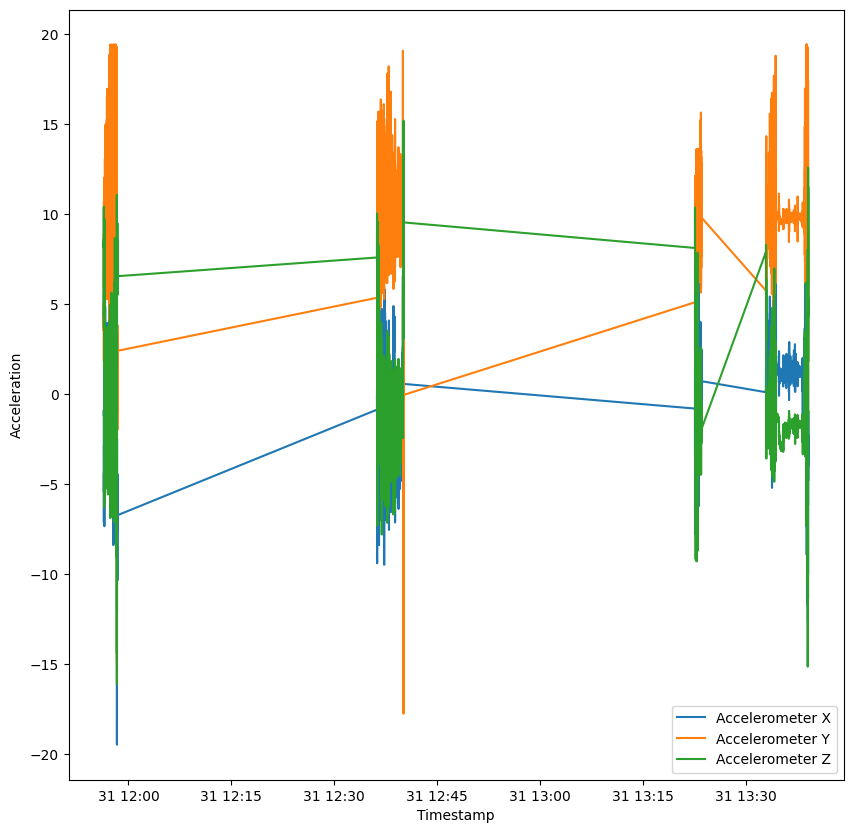

In [15]:
plt.figure(figsize=(10,10))
plt.plot(data['timestamp'], data['accelerometerX'], label='Accelerometer X')
plt.plot(data['timestamp'], data['accelerometerY'], label='Accelerometer Y')
plt.plot(data['timestamp'], data['accelerometerZ'],
label='Accelerometer Z')
plt.xlabel('Timestamp')
plt.ylabel('Acceleration')
plt.legend()
plt.show()

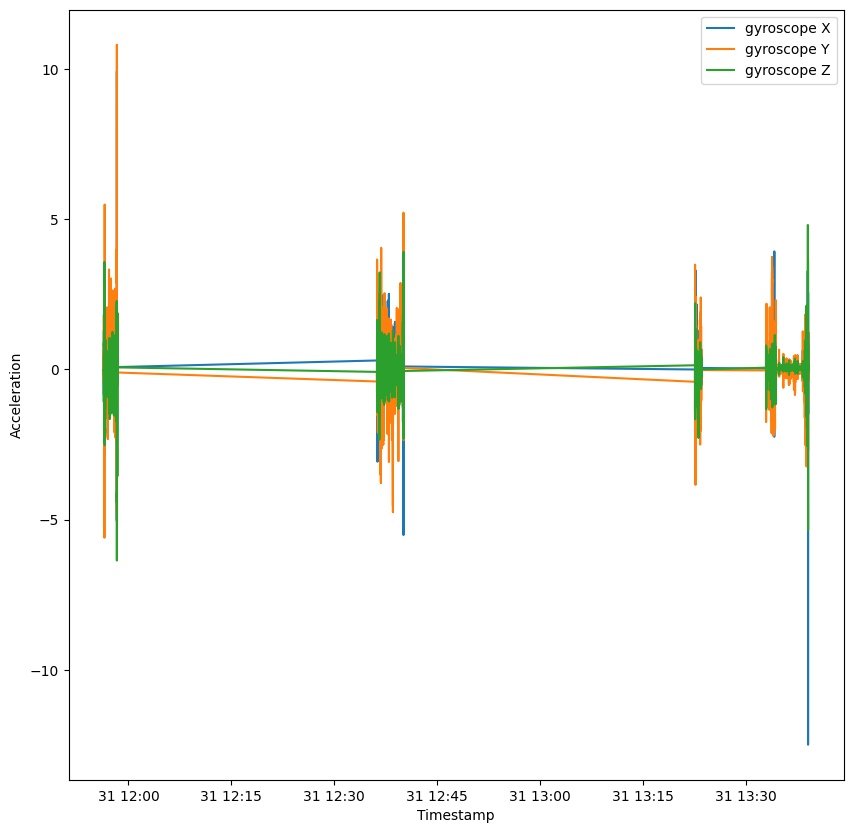

In [14]:
plt.figure(figsize=(10,10))
plt.plot(data['timestamp'], data['gyroscopeX'], label='gyroscope X')
plt.plot(data['timestamp'], data['gyroscopeY'], label='gyroscope Y')
plt.plot(data['timestamp'], data['gyroscopeZ'], label='gyroscope Z')
plt.xlabel('Timestamp')
plt.ylabel('Acceleration')
plt.legend()
plt.show()

# First impression

The raw sensor data was recorded on different days, therefore there are huge gaps on the graph - to ensure no gaps i will sample the data

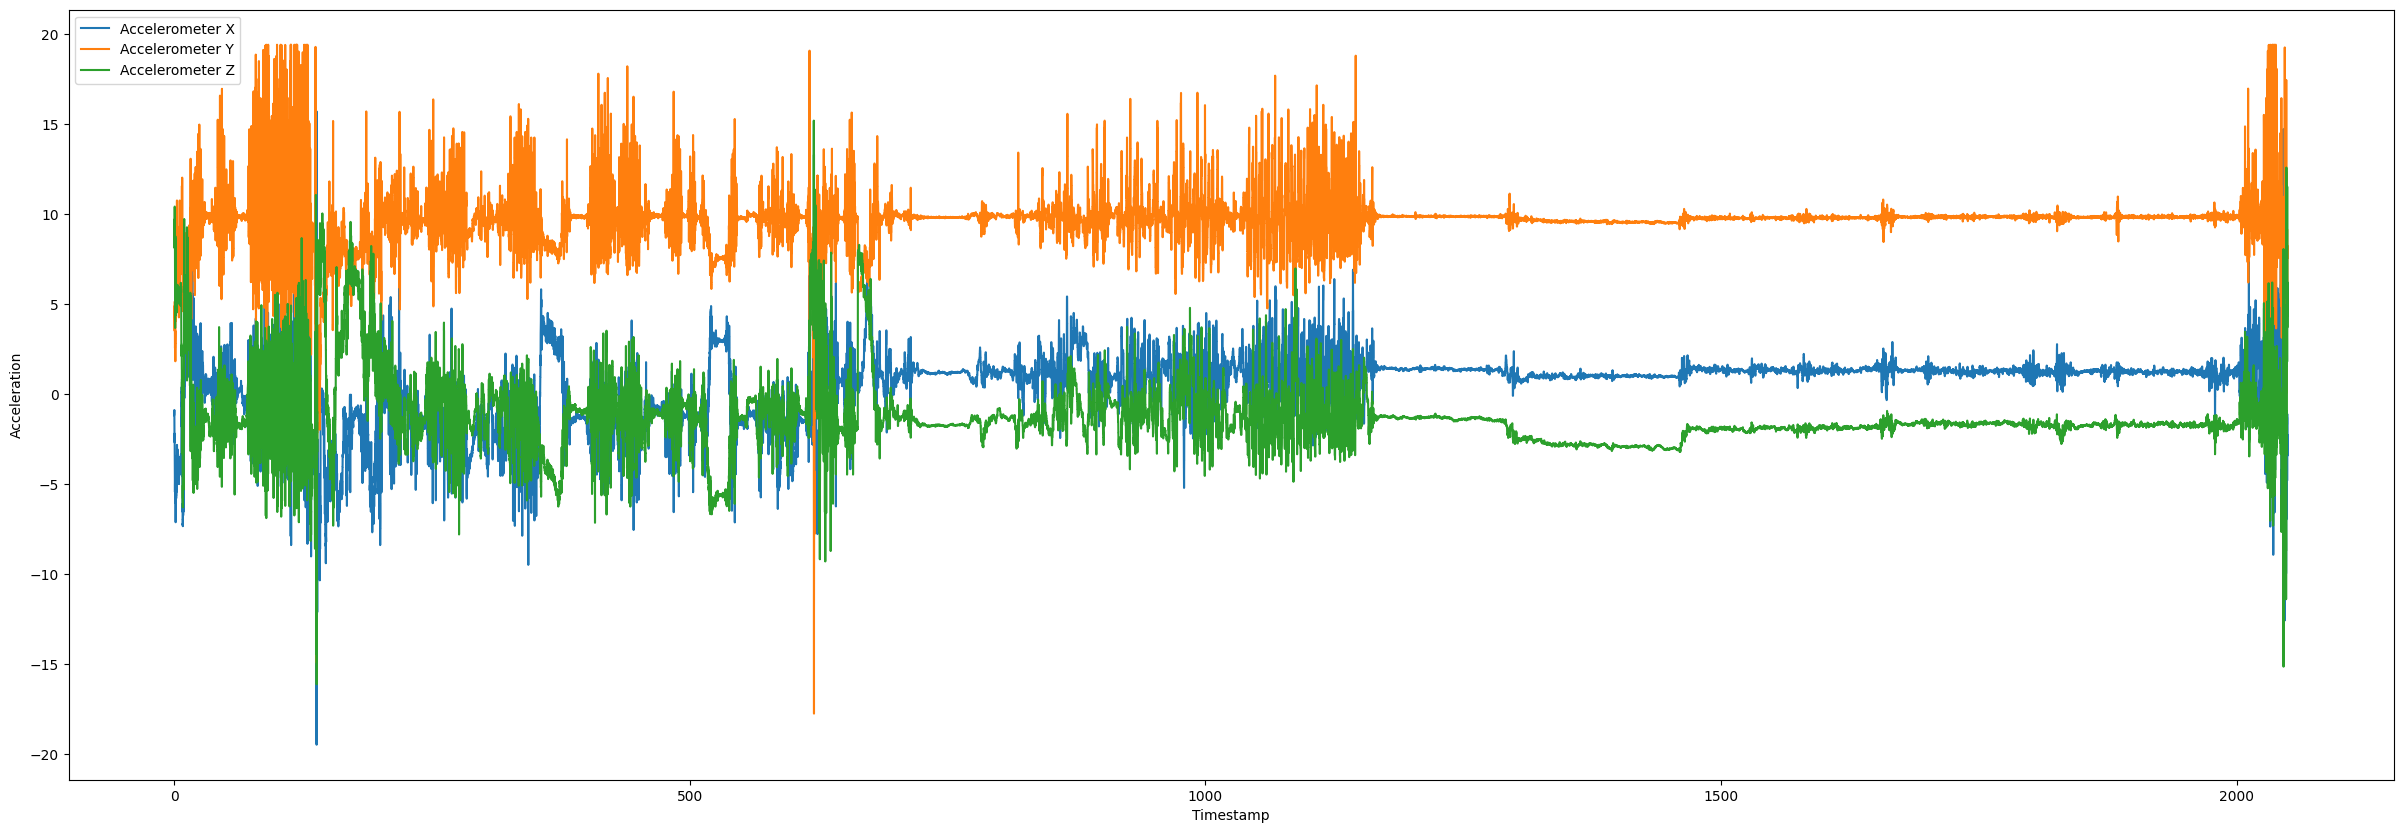

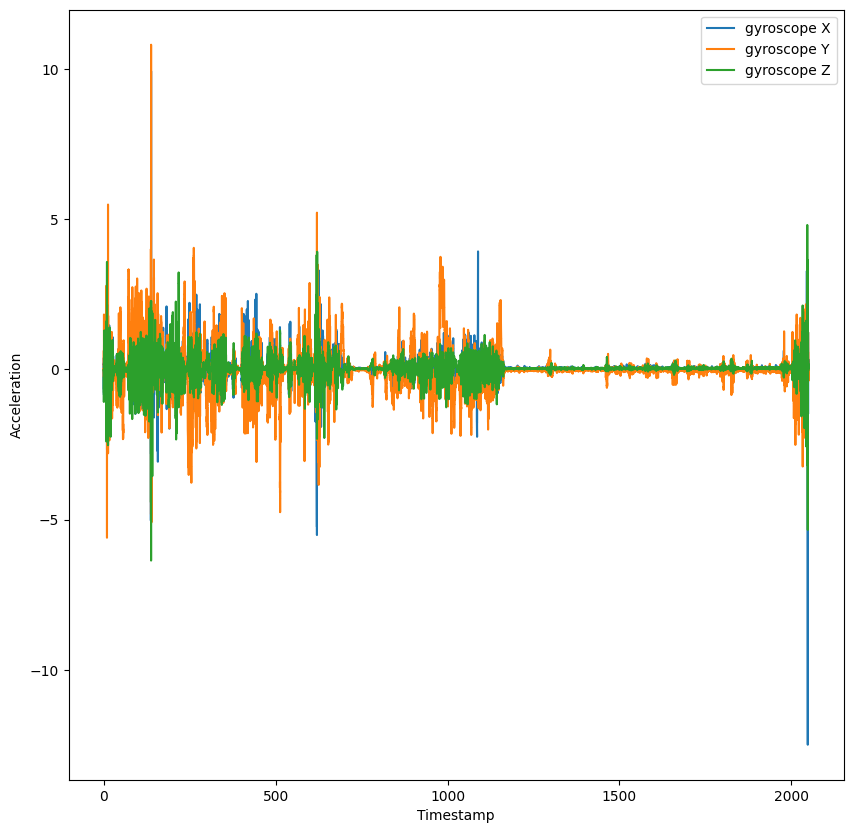

In [22]:
sampling_rate = 50.0
data['t_seconds'] = data.index / sampling_rate

plt.figure(figsize=(30,10))
plt.plot(data['t_seconds'], data['accelerometerX'], label='Accelerometer X')
plt.plot(data['t_seconds'], data['accelerometerY'], label='Accelerometer Y')
plt.plot(data['t_seconds'], data['accelerometerZ'],
label='Accelerometer Z')
plt.xlabel('Timestamp')
plt.ylabel('Acceleration')
plt.legend()
plt.show()

plt.figure(figsize=(10,10))
plt.plot(data['t_seconds'], data['gyroscopeX'], label='gyroscope X')
plt.plot(data['t_seconds'], data['gyroscopeY'], label='gyroscope Y')
plt.plot(data['t_seconds'], data['gyroscopeZ'], label='gyroscope Z')
plt.xlabel('Timestamp')
plt.ylabel('Acceleration')


plt.legend()
plt.show()

Now i don't have gaps, but the data still doesn't say anything - i need to somehow place labels

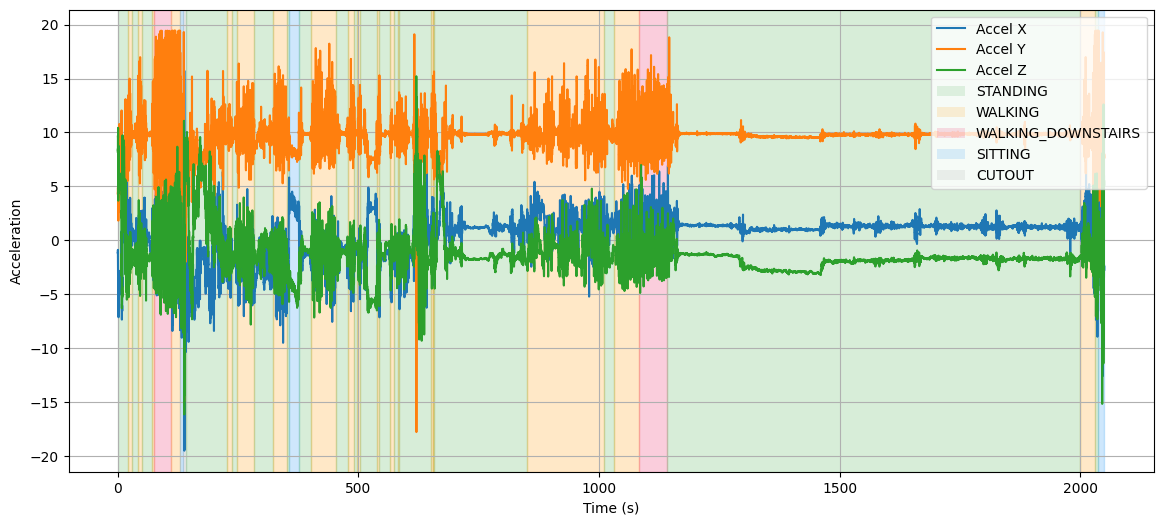

In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(14,6))

# plot your signals normally
ax.plot(data['t_seconds'], data['accelerometerX'], label='Accel X')
ax.plot(data['t_seconds'], data['accelerometerY'], label='Accel Y')
ax.plot(data['t_seconds'], data['accelerometerZ'], label='Accel Z')

# ---- make a color per unique label ----
labels = data['label'].unique()

label_colors = {
    "STANDING": "#4CAF50",          # green
    "SITTING": "#2196F3",           # blue
    "WALKING": "#FF9800",           # orange
    "WALKING_DOWNSTAIRS": "#E91E63",
    "CUTOUT": "#9E9E9E"             # gray
}

for _, chunk in data.groupby((data['label'] != data['label'].shift()).cumsum()):
    sub = data.loc[chunk.index]
    start = sub['t_seconds'].min()
    end   = sub['t_seconds'].max()
    activity = sub['label'].iloc[0]

    ax.axvspan(start, end,
               color=label_colors.get(activity, "#BBBBBB"),
               alpha=0.22)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Acceleration")
ax.grid(True)

# legend: one entry per label + keep the signal legend
activity_handles = [
    Patch(facecolor=label_colors[lbl], alpha=0.15, label=lbl)
    for lbl in labels
]

signal_handles, signal_labels = ax.get_legend_handles_labels()
ax.legend(signal_handles + activity_handles,
          signal_labels + list(labels),
          loc="upper right")

plt.show()


Now i want to split it into multiple graphs for better visibility

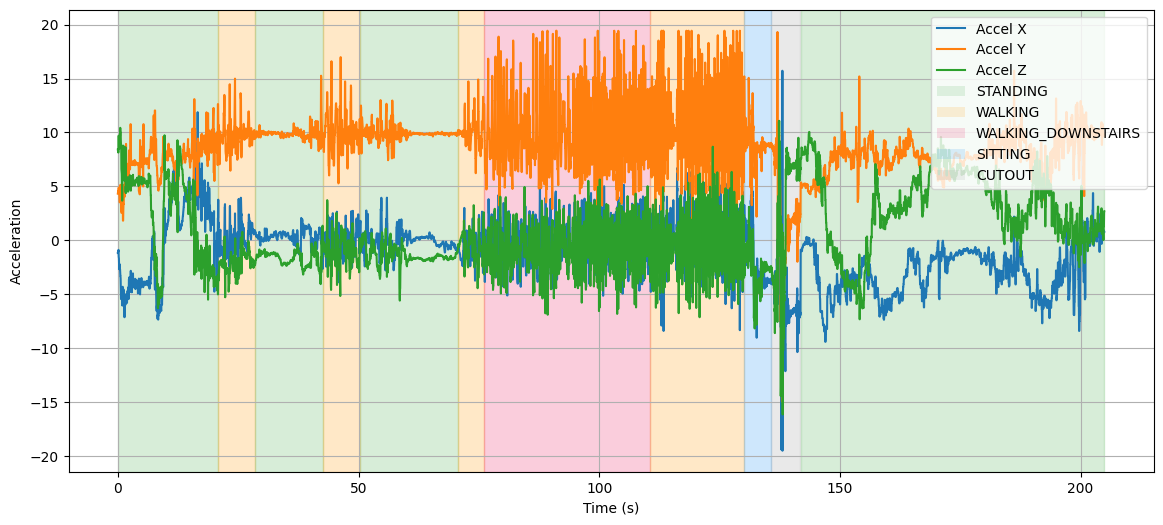

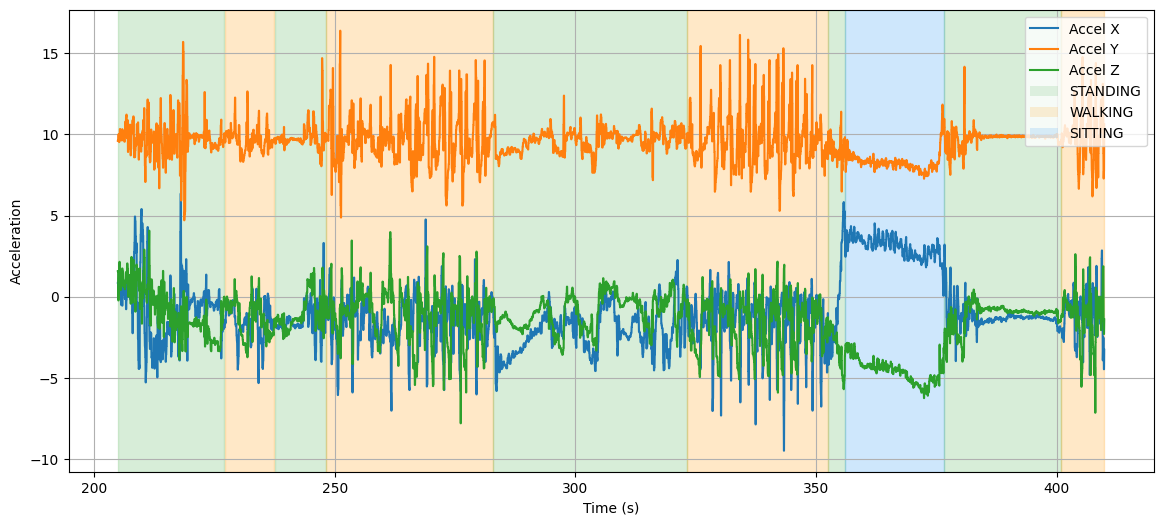

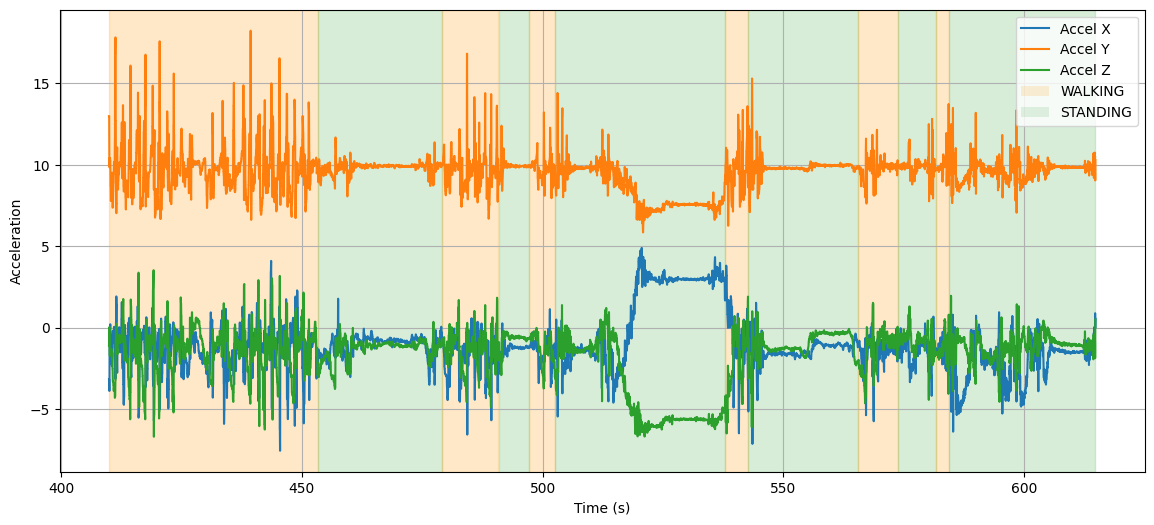

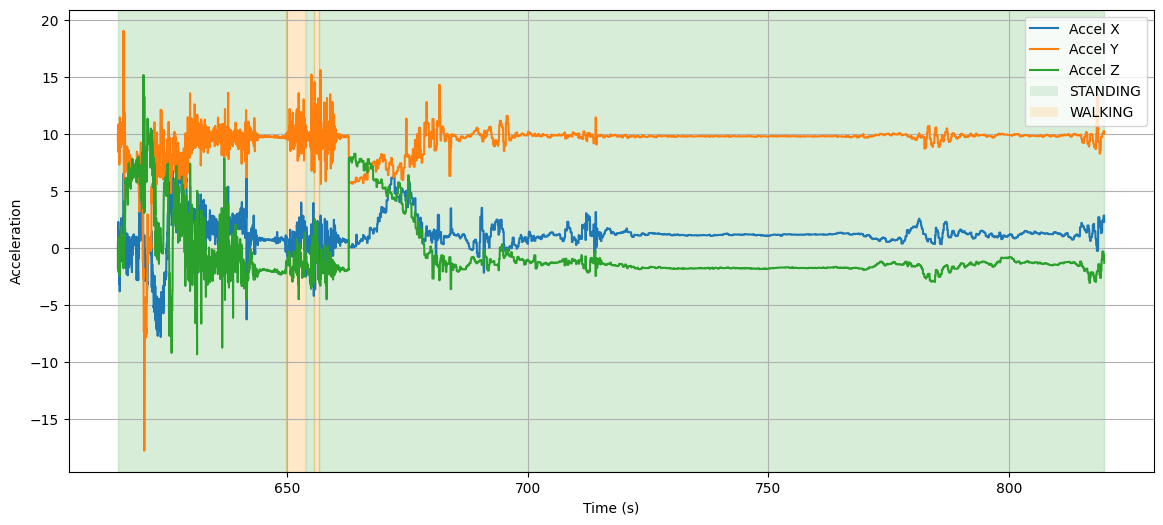

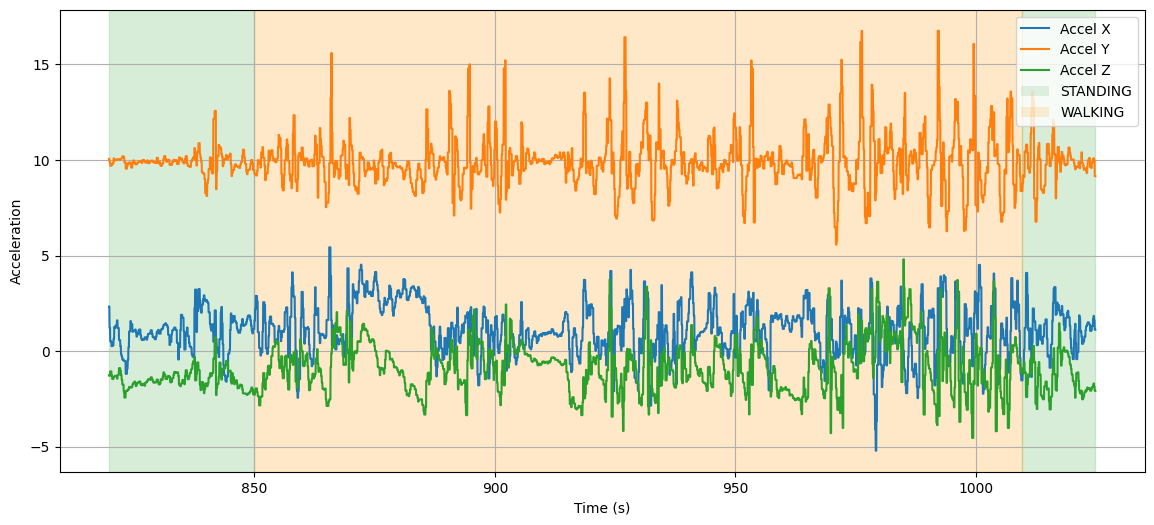

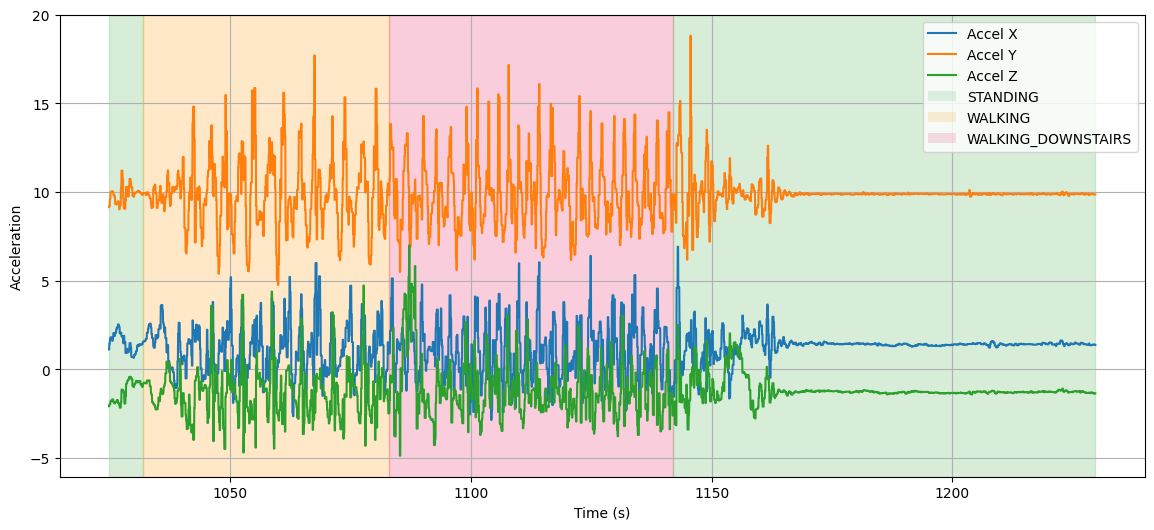

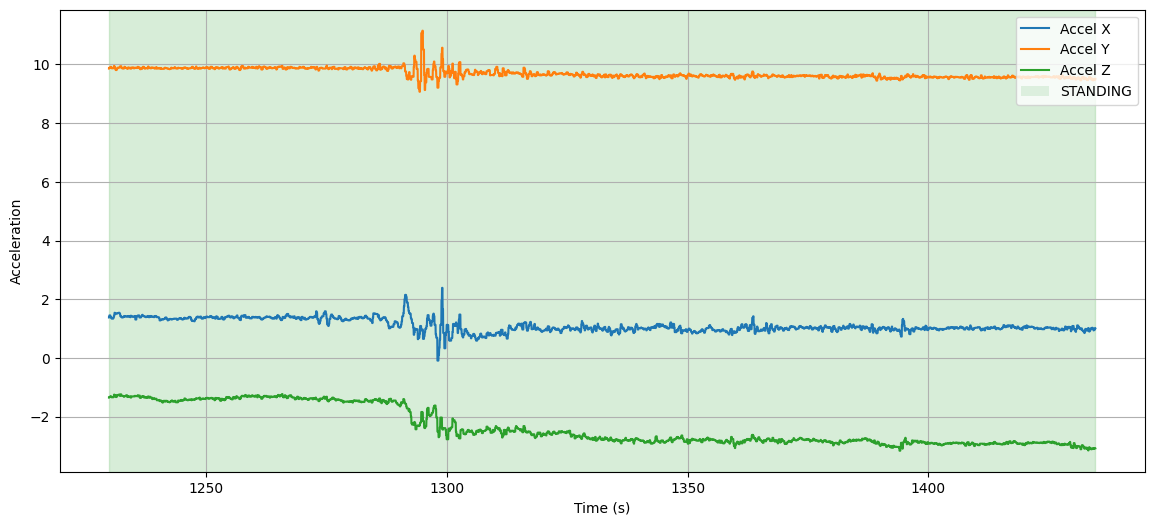

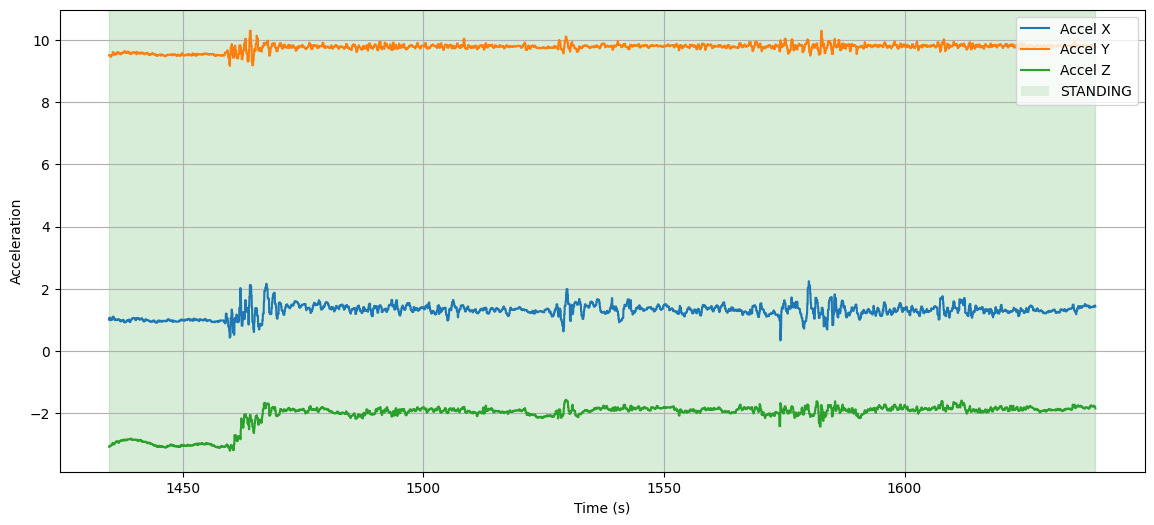

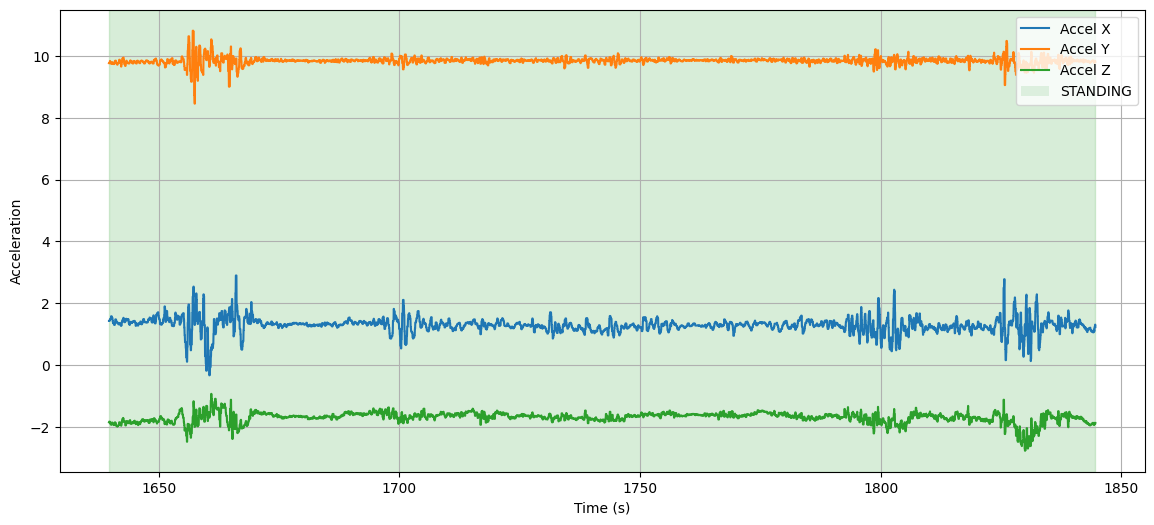

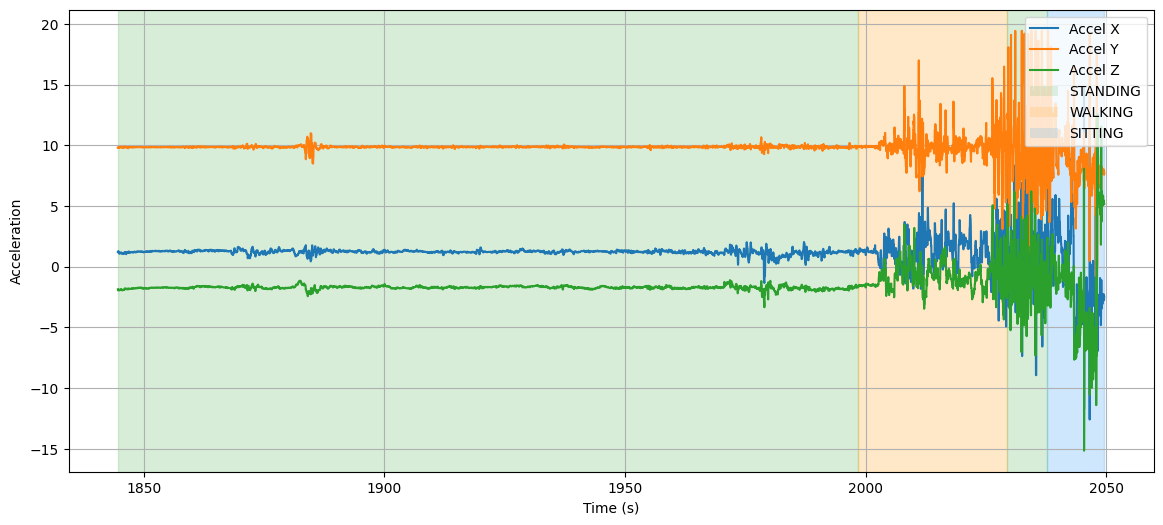

In [34]:
intervals = len(data) // 10
start_index = 0
for i in range(0,10):
    end_index = start_index + intervals
    segment = data[start_index:end_index]
    

    fig, ax = plt.subplots(figsize=(14,6))

    # plot your signals normally
    ax.plot(segment['t_seconds'], segment['accelerometerX'], label='Accel X')
    ax.plot(segment['t_seconds'], segment['accelerometerY'], label='Accel Y')
    ax.plot(segment['t_seconds'], segment['accelerometerZ'], label='Accel Z')

    # ---- make a color per unique label ----
    labels = segment['label'].unique()

    label_colors = {
        "STANDING": "#4CAF50",          # green
        "SITTING": "#2196F3",           # blue
        "WALKING": "#FF9800",           # orange
        "WALKING_DOWNSTAIRS": "#E91E63",
        "CUTOUT": "#9E9E9E"             # gray
    }

    for _, chunk in segment.groupby((segment['label'] != segment['label'].shift()).cumsum()):
        sub = segment.loc[chunk.index]
        start = sub['t_seconds'].min()
        end   = sub['t_seconds'].max()
        activity = sub['label'].iloc[0]

        ax.axvspan(start, end,
                color=label_colors.get(activity, "#BBBBBB"),
                alpha=0.22)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Acceleration")
    ax.grid(True)

    # legend: one entry per label + keep the signal legend
    activity_handles = [
        Patch(facecolor=label_colors[lbl], alpha=0.15, label=lbl)
        for lbl in labels
    ]

    signal_handles, signal_labels = ax.get_legend_handles_labels()
    ax.legend(signal_handles + activity_handles,
            signal_labels + list(labels),
            loc="upper right")

    plt.show()
    start_index = end_index + 1
    
    

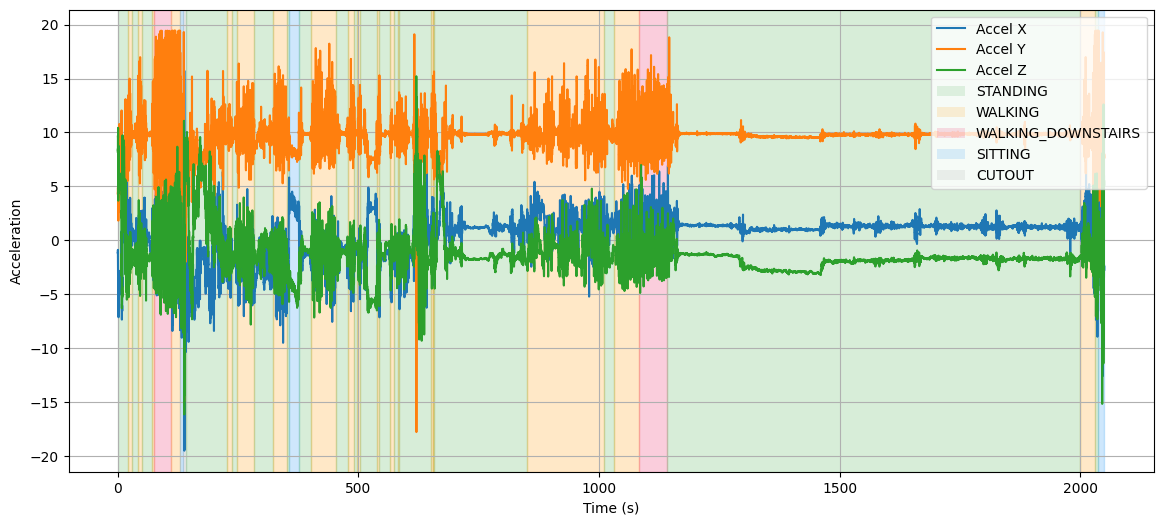